---
title: "Band-integrated forward model + plume injection"
---

# Band integration, forward models & nB-LUT plume injection

The line-by-line LUT from notebook 01 gives $\sigma(\nu, T, P)$ at fine wavenumber resolution. Real multispectral instruments observe *band-integrated* radiance — each band $b$ collects photons across a wavelength window weighted by its Spectral Response Function (SRF) $f_b(\lambda)$. This notebook closes the loop from the HR LUT to per-pixel band radiance via three steps:

1. **Forward models side-by-side.** Three flavours of Beer–Lambert — exact, Maclaurin, and Taylor — exposed through `plume_simulation.radtran.forward`. We plot them at a single wavenumber to see where the linearisations break.
2. **SRF band integration.** Build a Gaussian SRF at two S2-like bands (B11 @ 1610 nm, B12 @ 2190 nm) and apply it to a per-wavelength transmittance spectrum.
3. **Normalised-brightness LUT.** Pre-tabulate $nB_b(\Delta X) = \int f_b(\lambda)\, \exp[-\mathrm{AMF}\cdot\sigma(\lambda)\cdot\Delta X]\,d\lambda\,/\,\int f_b(\lambda)\,d\lambda$ over a 1-D grid of column enhancements, then apply it per-pixel to a clean synthetic scene via `inject_plume`.

Notebook 05 builds on this to do a matched-filter retrieval. The physics is derived in [00_hapi_lut_derivation.md](../hapi_lut/00_hapi_lut_derivation.md) (same Beer–Lambert start) and motivated by Orbio's Project Eucalyptus `Radiative_Transfer.md` — which argues that at the single-slab, band-integrated level the nB-LUT cancels most of the aerosol / albedo ignorance to first order.

In [1]:
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from plume_simulation.gauss_plume import simulate_plume
from plume_simulation.radtran import (
    InstrumentSpec,
    ObservationGeometry,
    build_nb_lut,
    forward_maclaurin_normalized,
    forward_nonlinear_normalized,
    forward_taylor_normalized,
    inject_plume,
    lookup_nb,
)

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pixi.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
LUT_PATH = REPO_ROOT / "projects" / "plume_simulation" / "data" / "hapi_lut" / "ch4_absorption_lut.nc"
assert LUT_PATH.exists(), f"Run 01_hapi_lut_ch4.ipynb first — missing {LUT_PATH}"

ch4_lut = xr.open_dataset(LUT_PATH)
nu_grid = ch4_lut["wavenumber"].values
wl_grid = ch4_lut["wavelength"].values
print(f"LUT spans {nu_grid.min():.0f}-{nu_grid.max():.0f} cm^-1 "
      f"(λ ≈ {wl_grid.max():.0f}-{wl_grid.min():.0f} nm), {nu_grid.size} points.")

LUT spans 4000-4500 cm^-1 (λ ≈ 2500-2222 nm), 10000 points.


## 1. Atmospheric state and viewing geometry

Mid-troposphere state — same as notebook 03. The `ObservationGeometry` dataclass packs the solar / viewing angles plus the single-slab vertical path into one immutable object; the air-mass factor is derived from the plane-parallel formula.

In [2]:
geom = ObservationGeometry(
    sza_deg=30.0,
    vza_deg=0.0,       # nadir
    path_length_cm=8e5,  # 8 km tropospheric column
)
T_K = 260.0
p_atm = 0.6
print(f"AMF = {geom.air_mass_factor:.3f}")

# Background CH4 mixing ratio (current global mean ~1.9 ppm).
VMR_BG = 1.9e-6

AMF = 2.155


## 2. Forward-model flavours

All three models return a `ForwardResult(radiance, jacobian, transmittance)`. Below we sweep $\Delta\mathrm{VMR}$ at the strongest CH$_4$ absorption line in our LUT (~4300 cm⁻¹, ≈ 2326 nm) and plot the normalised radiance $L_\text{norm} = L/L_\text{bg}$. The Maclaurin-1 variant is the linear matched-filter assumption; the Taylor-1 around the background collapses to the same at first order (we show only Maclaurin here). The nonlinear curve exposes where linearisations break.

Representative line: ν = 4267.1 cm^-1 (λ = 2343.5 nm), σ = 8.52e-21 cm²/molec


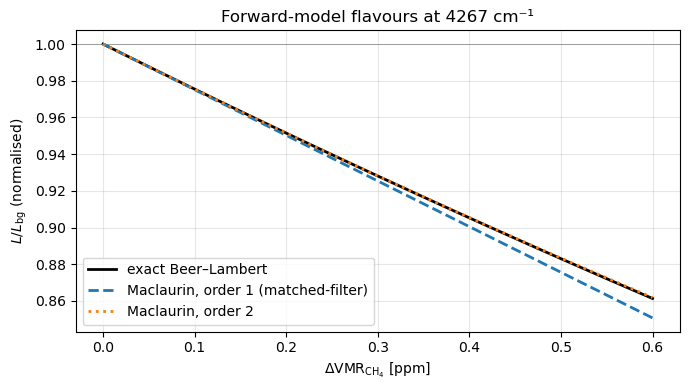

In [3]:
# Use a representative absorption line — the median of the nonzero σ values
# in the Q-branch. The LUT's absolute peak is unusually strong and would push
# the Maclaurin expansions off-scale before they can trace the nonlinear curve.
sigma_at_T_p = ch4_lut["absorption_cross_section"].interp(temperature=T_K, pressure=p_atm).values
strong_mask = sigma_at_T_p > np.quantile(sigma_at_T_p, 0.95)
nu_strong = float(nu_grid[np.where(strong_mask)[0][len(np.where(strong_mask)[0]) // 2]])
sigma_strong = float(sigma_at_T_p[np.argmin(np.abs(nu_grid - nu_strong))])
print(f"Representative line: ν = {nu_strong:.1f} cm^-1 (λ = {1e7/nu_strong:.1f} nm), "
      f"σ = {sigma_strong:.2e} cm²/molec")

delta_vmrs = np.linspace(0, 0.6e-6, 61)  # 0 to 0.6 ppm — the matched-filter regime
L_nl = np.empty_like(delta_vmrs)
L_m1 = np.empty_like(delta_vmrs)
L_m2 = np.empty_like(delta_vmrs)

common_kw = dict(
    T_K=T_K, p_atm=p_atm,
    path_length_cm=geom.path_length_cm, amf=geom.air_mass_factor,
)
for i, dvmr in enumerate(delta_vmrs):
    L_nl[i] = forward_nonlinear_normalized(
        ch4_lut, np.array([nu_strong]),
        vmr_background=VMR_BG, delta_vmr=float(dvmr), **common_kw,
    ).radiance[0]
    L_m1[i] = forward_maclaurin_normalized(
        ch4_lut, np.array([nu_strong]),
        delta_vmr=float(dvmr), order=1, **common_kw,
    ).radiance[0]
    L_m2[i] = forward_maclaurin_normalized(
        ch4_lut, np.array([nu_strong]),
        delta_vmr=float(dvmr), order=2, **common_kw,
    ).radiance[0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(delta_vmrs * 1e6, L_nl, "k-",  lw=2, label="exact Beer–Lambert")
ax.plot(delta_vmrs * 1e6, L_m1, "C0--", lw=2, label="Maclaurin, order 1 (matched-filter)")
ax.plot(delta_vmrs * 1e6, L_m2, "C1:",  lw=2, label="Maclaurin, order 2")
ax.axhline(1.0, color="gray", lw=0.5)
ax.set_xlabel(r"$\Delta\mathrm{VMR}_{\mathrm{CH}_4}$ [ppm]")
ax.set_ylabel(r"$L / L_{\mathrm{bg}}$ (normalised)")
ax.set_title(f"Forward-model flavours at {nu_strong:.0f} cm⁻¹")
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The three curves agree to within a fraction of a percent up to ~0.2 ppm, after which the exact Beer–Lambert model bends below the linear approximation. Order-2 Maclaurin tracks the nonlinear curve to ~0.5 ppm. Beyond that the expansions diverge quickly — but 0.5 ppm is already several times larger than the per-pixel enhancement in a typical oil-and-gas leak, so the matched filter's linear assumption is safe in the ordinary regime.

## 3. Synthetic multispectral instrument and SRF

`InstrumentSpec` describes a two-band Gaussian-SRF instrument patterned on Sentinel-2 B11/B12 (but nothing in the radtran package is S2-specific — swap in measured SRFs via `SpectralResponseFunction(srf_type='custom', custom_srfs=...)`).

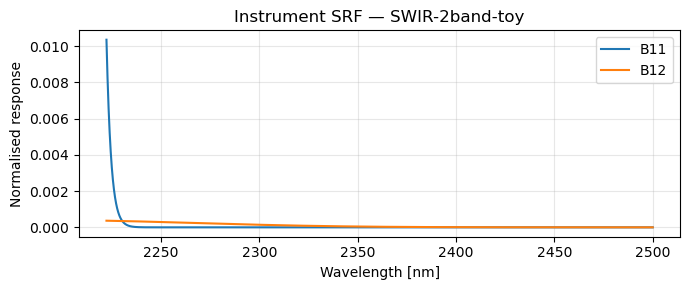

In [4]:
instrument = InstrumentSpec(
    name="SWIR-2band-toy",
    band_centers_nm=np.array([1610.0, 2190.0]),
    band_widths_nm=np.array([90.0, 180.0]),  # FWHM for gaussian
    band_names=("B11", "B12"),
    srf_type="gaussian",
)
# SRF on the LUT wavelength grid (sort ascending for the SRF internal ordering).
wl_ascending = np.sort(wl_grid)
srf = instrument.make_srf(wl_ascending)

fig, ax = plt.subplots(figsize=(7, 3))
for b in range(srf.n_bands):
    ax.plot(srf.wavelengths_hr_nm, srf.matrix[b], label=instrument.band_names[b])
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Normalised response")
ax.set_title(f"Instrument SRF — {instrument.name}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Normalised-brightness LUT

The nB-LUT pre-tabulates, for each band,

$$\mathrm{nB}_b(\Delta X) \;=\; \frac{\int f_b(\lambda)\, \exp\!\bigl[-\mathrm{AMF}\cdot\sigma(\lambda)\cdot\Delta X\bigr]\,d\lambda}{\int f_b(\lambda)\,d\lambda}\,, \qquad \Delta X \in [0, X_\text{max}]\ \text{mol/m}^2.$$

Per-pixel injection is then `nB_b(ΔX_map)` — one linear interpolation per pixel per band, irrespective of how many wavenumber points the underlying σ(ν) LUT has.

nB LUT: 2 bands × 2001 ΔX points (0 to 50 mol/m²)


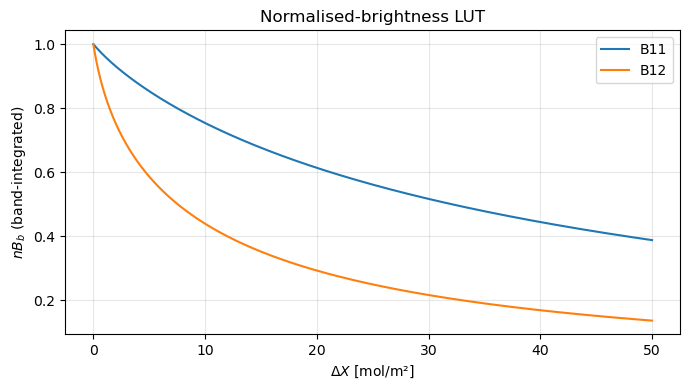

In [5]:
nb_lut = build_nb_lut(
    ch4_lut, srf,
    T_K=T_K, p_atm=p_atm,
    path_length_cm=geom.path_length_cm, amf=geom.air_mass_factor,
    max_delta_column=50.0, n_grid=2001,
)
print(f"nB LUT: {nb_lut.n_bands} bands × {nb_lut.n_delta} ΔX points "
      f"(0 to {nb_lut.delta_column[-1]:.0f} mol/m²)")

fig, ax = plt.subplots(figsize=(7, 4))
for b, name in enumerate(nb_lut.band_names):
    ax.plot(nb_lut.delta_column, nb_lut.nB[b], label=name)
ax.set_xlabel(r"$\Delta X$ [mol/m²]")
ax.set_ylabel(r"$nB_b$ (band-integrated)")
ax.set_title("Normalised-brightness LUT")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

B12 absorbs noticeably more than B11 — consistent with the 2190 nm window overlapping the stronger CH$_4$ $\nu_3$ Q-branch.

## 5. Plume injection into a synthetic scene

Build a Gaussian plume column map via `gauss_plume.simulate_plume`, then inject into a clean, unit-reflectance two-band scene. In a real pipeline this scene would be a radiance-rescaled Sentinel-2 tile; the injection mathematics (multiply clean B11/B12 by the band-integrated nB factor) is identical.

ΔX map shape: (61, 121), peak 51.77 mol/m²


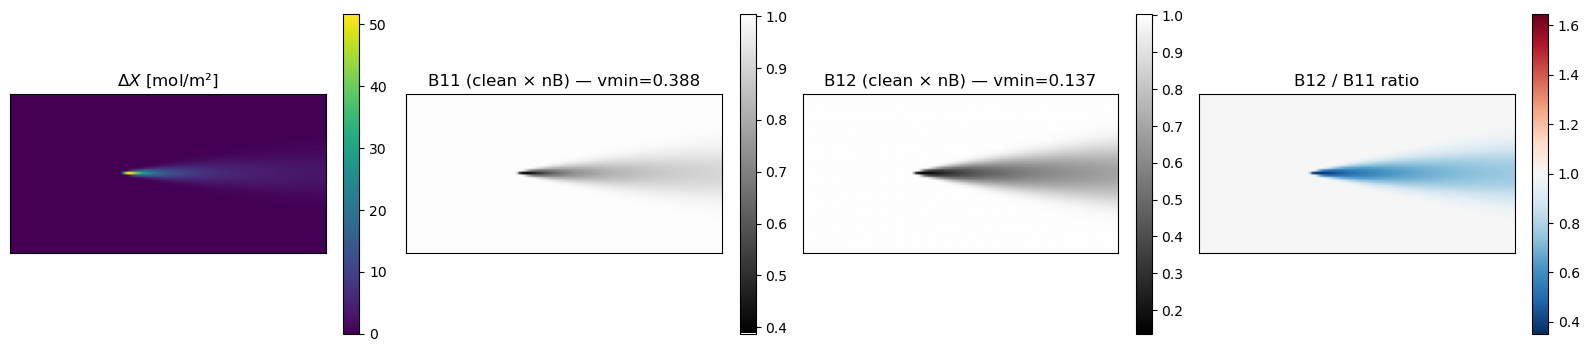

In [6]:
plume_ds = simulate_plume(
    emission_rate=10.0,              # kg/s ≈ 36000 kg/hr — strong for visibility
    source_location=(0.0, 0.0, 2.0),
    wind_speed=3.0,
    wind_direction=270.0,            # wind from the west → plume east
    stability_class="D",
    domain_x=(-200.0, 400.0, 121),
    domain_y=(-150.0, 150.0, 61),
    domain_z=(0.0, 50.0, 11),
)
# Convert column-integrated mass [kg/m²] → CH4 column in mol/m² (16 g/mol).
M_CH4 = 16.04e-3  # kg/mol
delta_X = (plume_ds["column_concentration"].values / M_CH4)
# gauss_plume returns a (x, y) field — rename to (ny, nx) for image-style plotting.
delta_X_map = delta_X.T  # (y, x)
print(f"ΔX map shape: {delta_X_map.shape}, peak {delta_X_map.max():.2f} mol/m²")

# Pretend clean scene: flat unit reflectance over B11 + B12.
ny, nx = delta_X_map.shape
clean_scene = np.ones((2, ny, nx), dtype=float)
dirty_scene = inject_plume(clean_scene, delta_X_map, nb_lut)

# Pick colour limits from the actual injected field so the plume is visible
# without clipping. Each band gets its own range because B11 absorbs less.
def _plume_limits(img):
    vmin = float(img.min())
    # Widen a hair above 1.0 so the background stripe is clearly "unity".
    return vmin, 1.005

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
im0 = axes[0].imshow(delta_X_map, origin="lower", cmap="viridis")
axes[0].set_title(r"$\Delta X$ [mol/m²]")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

vmin_b11, vmax_b11 = _plume_limits(dirty_scene[0])
im1 = axes[1].imshow(dirty_scene[0], origin="lower", cmap="gray", vmin=vmin_b11, vmax=vmax_b11)
axes[1].set_title(f"B11 (clean × nB) — vmin={vmin_b11:.3f}")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

vmin_b12, vmax_b12 = _plume_limits(dirty_scene[1])
im2 = axes[2].imshow(dirty_scene[1], origin="lower", cmap="gray", vmin=vmin_b12, vmax=vmax_b12)
axes[2].set_title(f"B12 (clean × nB) — vmin={vmin_b12:.3f}")
fig.colorbar(im2, ax=axes[2], fraction=0.046)

ratio = dirty_scene[1] / dirty_scene[0]
vr = max(abs(ratio.min() - 1.0), abs(ratio.max() - 1.0))
im3 = axes[3].imshow(ratio, origin="lower", cmap="RdBu_r", vmin=1 - vr, vmax=1 + vr)
axes[3].set_title("B12 / B11 ratio")
fig.colorbar(im3, ax=axes[3], fraction=0.046)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

The B12/B11 ratio plot is how classical matched-filter retrievals surface the plume footprint: methane absorbs more strongly in B12 than B11 so the ratio dips below 1 inside the plume. In notebook 05 we replace the visual check with a quantitative matched-filter retrieval that estimates the per-pixel column enhancement.

## 6. `lookup_nb` directly — diagnostic view

`inject_plume` is a thin wrapper around `lookup_nb` + multiplication. The lookup itself is useful standalone for diagnostics: the per-band nB map shows where each band "sees" the plume most strongly.

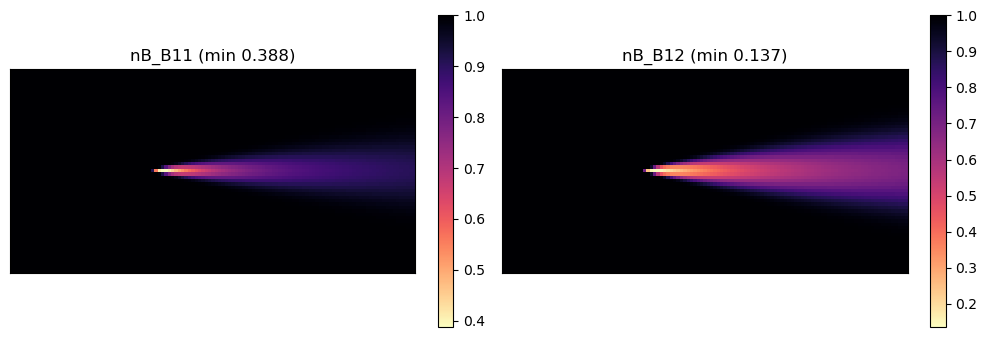

In [7]:
nb_map = lookup_nb(delta_X_map, nb_lut)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for b, name in enumerate(nb_lut.band_names):
    # Per-band vmin from the actual range; makes the plume visible without clipping.
    vmin = float(nb_map[b].min())
    im = axes[b].imshow(nb_map[b], origin="lower", cmap="magma_r",
                        vmin=vmin, vmax=1.0)
    axes[b].set_title(f"nB_{name} (min {vmin:.3f})")
    axes[b].set_xticks([]); axes[b].set_yticks([])
    fig.colorbar(im, ax=axes[b], fraction=0.046)
plt.tight_layout()
plt.show()

Both bands drop below 1 where the plume is dense, but the B12 dip is sharper. The next notebook uses this asymmetry to quantify $\Delta X$ via a matched-filter retrieval.